# QDMpy ODMR Processors Tutorial

This tutorial demonstrates the ODMR processing capabilities of QDMpy, particularly focusing on the modular processor framework. We'll explore how to:

1. Load ODMR data from MATLAB files
2. Create and configure a processing pipeline
3. Apply various processors (normalization, outlier rejection, binning, etc.)
4. Visualize the results at each processing step
5. Work with the newly implemented fluorescence correction techniques

Let's begin!

## 1. Setup and Imports

First, let's import the necessary libraries and components.

In [5]:
from __future__ import annotations

import sys

sys.path.append("home/mike/git/QDMpy/src")

In [6]:
import os

import matplotlib.pyplot as plt
import numpy as np

# For better visualization
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 8)

# Import QDMpy components
import contextlib

from QDMpy.odmr.data import ODMRData
from QDMpy.odmr.io import MatlabLoader
from QDMpy.odmr.odmr import ODMR
from QDMpy.odmr.processors import (
    BinningProcessor,
    FluorescenceCorrectionProcessor,
    NormalizationProcessor,
    ODMRProcessorManager,
    OutlierProcessor,
    analyze_fluorescence_effects,
    preview_fluorescence_correction,
)

## 2. Loading ODMR Data

We'll load the example ODMR data from the test data directory.

In [7]:
# Path to the test data
data_folder = os.path.join(os.path.dirname(os.getcwd()), "tests", "data")

# Create a loader instance
loader = MatlabLoader(data_folder=data_folder)

# Load the data
try:
    raw_data, scan_dimensions, frequencies = loader.load()
except Exception:
    # If loading fails, create synthetic data for demonstration

    # Parameters for synthetic data
    n_polarities = 2
    n_freq_ranges = 1
    rows, cols = 20, 20
    n_pixels = rows * cols
    n_frequencies = 100

    # Create frequency axis (2.87-2.89 GHz range)
    frequencies = np.linspace(2.87e9, 2.89e9, n_frequencies)
    scan_dimensions = np.array([rows, cols], dtype=int)  # Ensure integer type

    # Create synthetic data with ODMR dips
    raw_data = np.ones((n_polarities, n_freq_ranges, n_pixels, n_frequencies))

    # Add realistic ODMR features with some noise
    freq_centers = [2.87e9 + 0.01e9, 2.87e9 + 0.015e9]
    for i in range(n_pixels):
        # Add dips at two positions (simulating NV resonances)
        for fc in freq_centers:
            dip_amplitude = 0.05 + 0.02 * np.random.randn()
            dip_width = 5e6 * (1 + 0.2 * np.random.randn())
            raw_data[0, 0, i, :] -= dip_amplitude * np.exp(
                -((frequencies - fc) ** 2) / (2 * dip_width**2)
            )
            raw_data[1, 0, i, :] -= dip_amplitude * np.exp(
                -((frequencies - (fc + 1e7)) ** 2) / (2 * dip_width**2)
            )

        # Add random noise
        raw_data[0, 0, i, :] += 0.005 * np.random.randn(n_frequencies)
        raw_data[1, 0, i, :] += 0.005 * np.random.randn(n_frequencies)

    # Add global fluorescence variation (spatial pattern across the image)
    x = np.linspace(-1, 1, rows)
    y = np.linspace(-1, 1, cols)
    xx, yy = np.meshgrid(x, y)
    spatial_pattern = np.exp(-(xx**2 + yy**2) / 0.5).flatten()

    # Apply spatial pattern to all frequencies
    for p in range(n_polarities):
        for f in range(n_freq_ranges):
            for i in range(n_frequencies):
                raw_data[p, f, :, i] *= 0.8 + 0.4 * spatial_pattern


Loading data from: /home/mike/git/tests/data
Error loading data: [Errno 2] No such file or directory: '/home/mike/git/tests/data'
Creating synthetic data for demonstration...
Created synthetic data with shape: (2, 1, 400, 100)
Scan dimensions: [20 20]


## 3. Creating an ODMR Data Object

Let's create an ODMRData object from the loaded data.

In [8]:
# Create an ODMRData object
odmr_data = ODMRData(raw_data, scan_dimensions, frequencies)

# Display basic information

ODMR data shape: (2, 1, 400, 100)
Number of pixels: 400
Number of frequency points: 100
Frequency range: 2.8700 GHz to 2.8900 GHz


## 4. Visualizing Raw ODMR Data

Let's visualize the raw ODMR data to understand what we're working with.

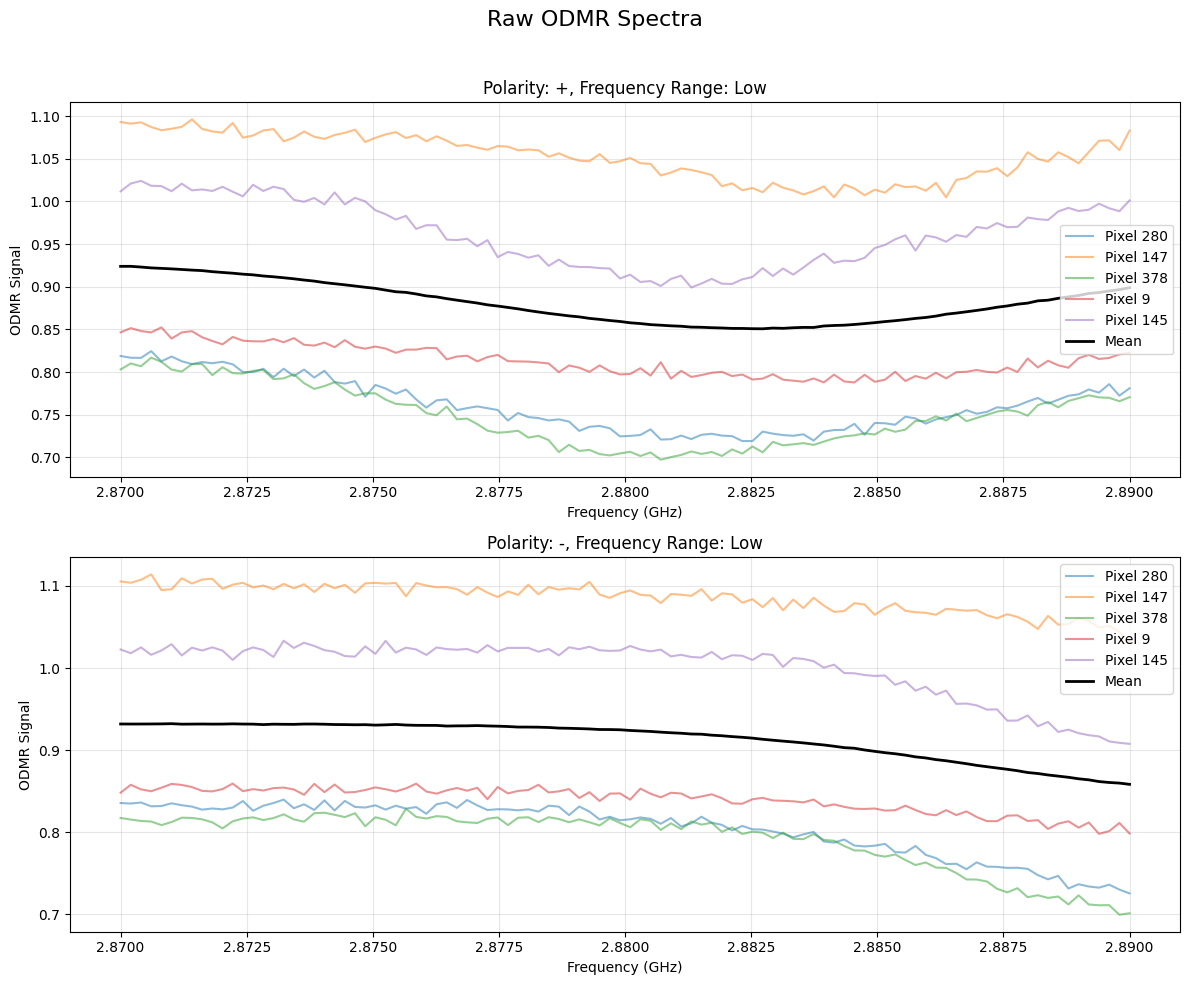

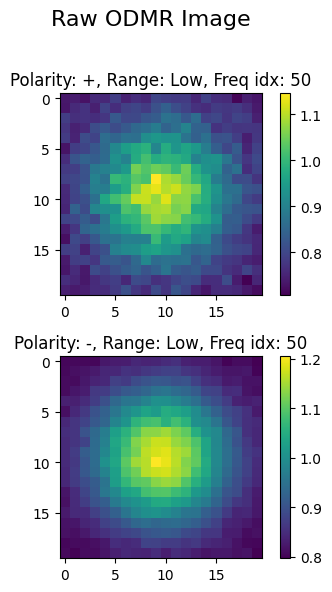

In [9]:
def visualize_odmr_spectra(data, frequencies, pixels=None, title="ODMR Spectra") -> None:
    """Visualize ODMR spectra for specific pixels."""
    # If no pixels specified, choose a few random ones and the mean
    n_pixels = data.shape[2]
    if pixels is None:
        pixels = np.random.choice(n_pixels, size=5, replace=False)

    fig, axes = plt.subplots(data.shape[0], data.shape[1], figsize=(12, 5 * data.shape[0]))

    # Handle single subplot case
    if data.shape[0] == 1 and data.shape[1] == 1:
        axes = np.array([[axes]])
    elif data.shape[0] == 1:
        axes = np.array([axes])
    elif data.shape[1] == 1:
        axes = np.array([axes]).T

    # Plot for each polarity and frequency range
    for p in range(data.shape[0]):
        for f in range(data.shape[1]):
            # Plot individual pixel spectra
            for pixel in pixels:
                axes[p, f].plot(
                    frequencies / 1e9, data[p, f, pixel, :], alpha=0.5, label=f"Pixel {pixel}"
                )

            # Plot mean spectrum
            mean_spectrum = np.mean(data[p, f], axis=0)
            axes[p, f].plot(frequencies / 1e9, mean_spectrum, "k-", linewidth=2, label="Mean")

            # Set titles and labels
            polarity_label = {0: "+", 1: "-"}.get(p, f"P{p}")
            frange_label = {0: "Low", 1: "High"}.get(f, f"F{f}")
            axes[p, f].set_title(f"Polarity: {polarity_label}, Frequency Range: {frange_label}")
            axes[p, f].set_xlabel("Frequency (GHz)")
            axes[p, f].set_ylabel("ODMR Signal")
            axes[p, f].legend()
            axes[p, f].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def visualize_odmr_image(data, scan_dimensions, freq_idx=None, title="ODMR Image") -> None:
    """Visualize ODMR data as spatial images."""
    # If no frequency index specified, use the middle one
    if freq_idx is None:
        freq_idx = data.shape[3] // 2

    fig, axes = plt.subplots(
        data.shape[0], data.shape[1], figsize=(4 * data.shape[1], 3 * data.shape[0])
    )

    # Handle single subplot case
    if data.shape[0] == 1 and data.shape[1] == 1:
        axes = np.array([[axes]])
    elif data.shape[0] == 1:
        axes = np.array([axes])
    elif data.shape[1] == 1:
        axes = np.array([axes]).T

    # Create a scientific colormap
    cmap = plt.cm.viridis

    # Plot for each polarity and frequency range
    for p in range(data.shape[0]):
        for f in range(data.shape[1]):
            # Reshape 1D pixel array to 2D image
            image = data[p, f, :, freq_idx].reshape(scan_dimensions)

            # Plot image
            im = axes[p, f].imshow(image, cmap=cmap)
            plt.colorbar(im, ax=axes[p, f])

            # Set titles
            polarity_label = {0: "+", 1: "-"}.get(p, f"P{p}")
            frange_label = {0: "Low", 1: "High"}.get(f, f"F{f}")
            axes[p, f].set_title(
                f"Polarity: {polarity_label}, Range: {frange_label}, Freq idx: {freq_idx}"
            )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Visualize the raw data
visualize_odmr_spectra(odmr_data.data, odmr_data.frequencies, title="Raw ODMR Spectra")
visualize_odmr_image(odmr_data.data, odmr_data.scan_dimensions, title="Raw ODMR Image")

## 5. Setting Up the Processing Pipeline

Now let's set up a processing pipeline using the `ODMRProcessorManager` and add various processors to it.

In [10]:
# Create an ODMR instance with our data
odmr = ODMR(odmr_data)

# Initialize an empty processor manager
processor_manager = ODMRProcessorManager()

# Add the processor manager to our ODMR instance
odmr.processor_manager = processor_manager


Initialized ODMR instance with empty processor pipeline.


## 6. Applying Processors Step by Step

Let's examine each processor individually and see its effects on the data.

### Step 1: Outlier Rejection

First, let's identify and remove outliers in the ODMR spectra.

12:18:55.651    DEBUG QDMpy.odmr.processors.add_processor >> Adding processor: OutlierProcessor
12:18:55.653     INFO QDMpy.odmr.odmr.process_data >> Processing data.
12:18:55.653     INFO QDMpy.odmr.processors.process >> Starting processing pipeline.
12:18:55.653    DEBUG QDMpy.odmr.processors.process >> Applying processor: OutlierProcessor
12:18:55.654    DEBUG QDMpy.odmr.processors.process >> Masking outliers with threshold: 0.01
12:18:55.655     INFO QDMpy.odmr.processors.process >> Processing pipeline completed.
Applied outlier rejection with threshold=0.01


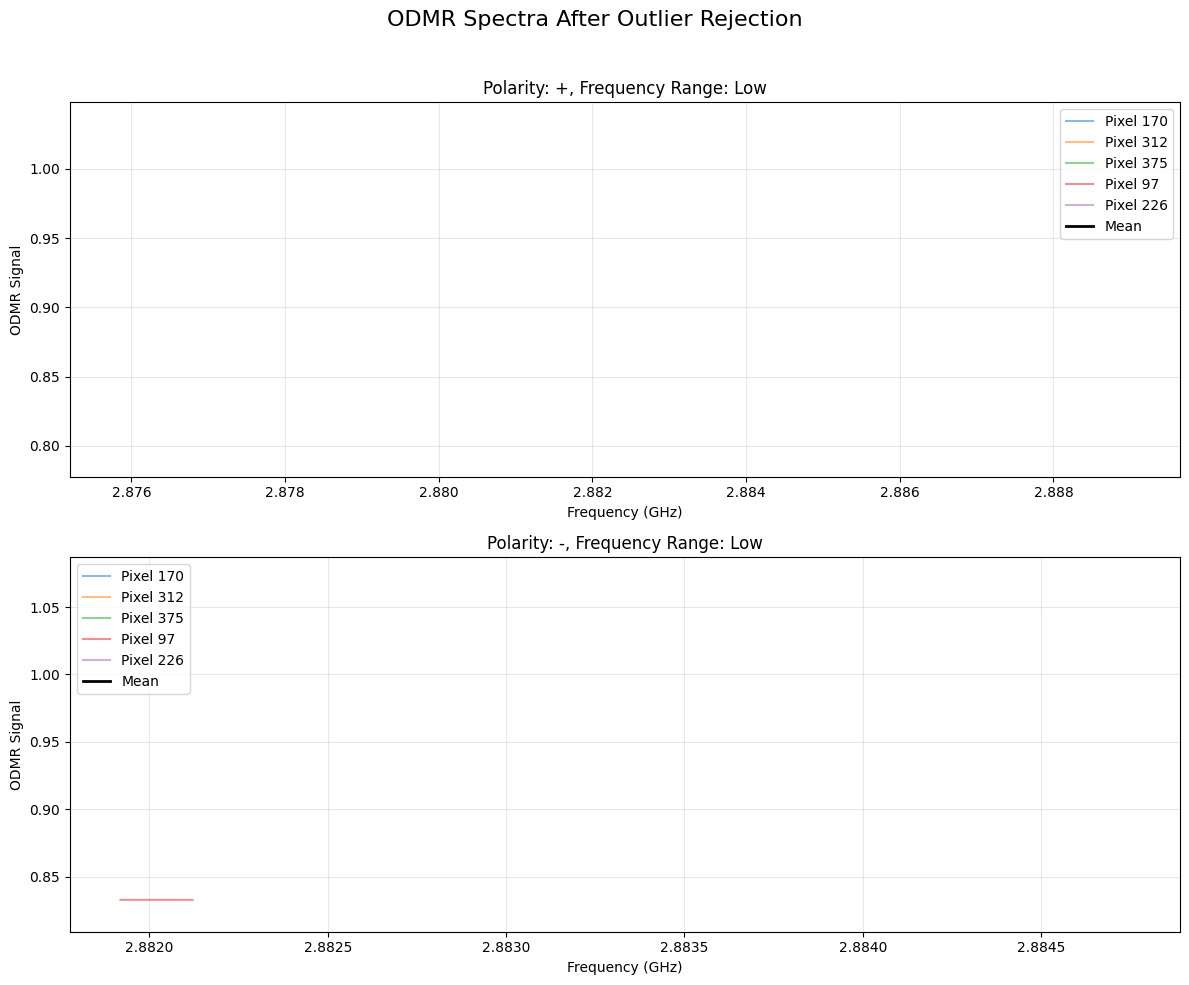

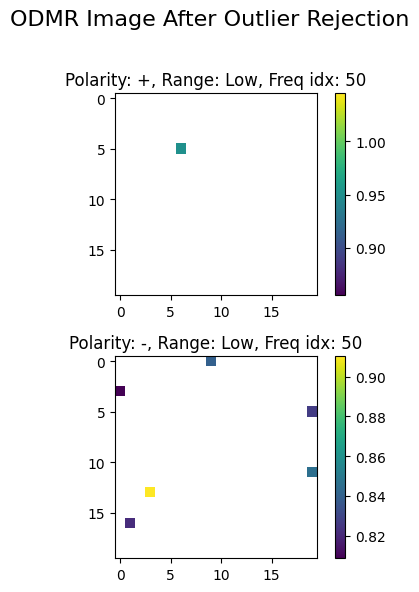

In [11]:
# Reset the processor manager to start fresh
odmr.processor_manager = ODMRProcessorManager()

# Add an outlier processor
odmr.processor_manager.add_processor(OutlierProcessor(threshold=0.01))

# Process the data
odmr.process_data()

# Display results
visualize_odmr_spectra(
    odmr.processed_data.data,
    odmr.processed_data.frequencies,
    title="ODMR Spectra After Outlier Rejection",
)
visualize_odmr_image(
    odmr.processed_data.data,
    odmr.processed_data.scan_dimensions,
    title="ODMR Image After Outlier Rejection",
)

### Step 2: Fluorescence Correction

Now, let's examine the global fluorescence patterns in the data and apply a correction. First, we'll use the new `analyze_fluorescence_effects` function to visualize the effects, then we'll try different correction factors.

In [ ]:
# Reset to raw data
odmr.reset()

# Use the analyze_fluorescence_effects function to understand the data
try:
    pixel_idx, baseline_corrected = analyze_fluorescence_effects(odmr.raw_data)

    # Preview different correction factors
    for factor in [0.0, 0.2, 0.5, 1.0]:
        preview_fluorescence_correction(
            odmr.raw_data, correction_factor=factor, pixel_idx=pixel_idx
        )
except Exception:
    # Use middle pixel as fallback if automatic selection fails
    pixel_idx = odmr.raw_data.data.shape[2] // 2

    # Preview different correction factors
    for factor in [0.0, 0.2, 0.5, 1.0]:
        preview_fluorescence_correction(
            odmr.raw_data, correction_factor=factor, pixel_idx=pixel_idx
        )

In [ ]:
# Now let's apply the fluorescence correction processor
odmr.processor_manager = ODMRProcessorManager()
odmr.processor_manager.add_processor(FluorescenceCorrectionProcessor(correction_factor=0.5))

# Process the data
odmr.process_data()

# Display results
visualize_odmr_spectra(
    odmr.processed_data.data,
    odmr.processed_data.frequencies,
    title="ODMR Spectra After Fluorescence Correction",
)
visualize_odmr_image(
    odmr.processed_data.data,
    odmr.processed_data.scan_dimensions,
    title="ODMR Image After Fluorescence Correction",
)

### Step 3: Normalization

Next, let's normalize the ODMR spectra to standardize the signal levels across pixels.

In [ ]:
# Reset to raw data
odmr.reset()

# Create a pipeline with fluorescence correction followed by normalization
odmr.processor_manager = ODMRProcessorManager()
odmr.processor_manager.add_processor(FluorescenceCorrectionProcessor(correction_factor=0.5))
odmr.processor_manager.add_processor(NormalizationProcessor(method="max"))

# Process the data
odmr.process_data()

# Display results
visualize_odmr_spectra(
    odmr.processed_data.data,
    odmr.processed_data.frequencies,
    title="ODMR Spectra After Fluorescence Correction and Normalization",
)
visualize_odmr_image(
    odmr.processed_data.data,
    odmr.processed_data.scan_dimensions,
    title="ODMR Image After Fluorescence Correction and Normalization",
)

### Step 4: Spatial Binning

Finally, let's apply spatial binning to improve the signal-to-noise ratio by combining neighboring pixels.

In [ ]:
# Reset to raw data
odmr.reset()

# Create a complete processing pipeline
odmr.processor_manager = ODMRProcessorManager()
odmr.processor_manager.add_processor(OutlierProcessor(threshold=0.01))
odmr.processor_manager.add_processor(FluorescenceCorrectionProcessor(correction_factor=0.5))
odmr.processor_manager.add_processor(NormalizationProcessor(method="max"))
odmr.processor_manager.add_processor(BinningProcessor(bin_factor=2))

# List the processors in our pipeline
for i, _processor in enumerate(odmr.processor_manager.list_processors()):
    pass

# Process the data
odmr.process_data()

# Display results

visualize_odmr_spectra(
    odmr.processed_data.data,
    odmr.processed_data.frequencies,
    title="ODMR Spectra After Complete Processing",
)
visualize_odmr_image(
    odmr.processed_data.data,
    odmr.processed_data.scan_dimensions,
    title="ODMR Image After Complete Processing",
)

## 7. Comparing Raw vs. Processed Data

Let's directly compare the raw and processed ODMR spectra and images to see the effects of our processing pipeline.

In [ ]:
# Function to compare raw and processed data
def compare_raw_processed(raw_data, processed_data, frequencies, raw_dims, proc_dims) -> None:
    # Select a representative pixel
    raw_pixel = raw_data.shape[2] // 2
    proc_pixel = processed_data.shape[2] // 2

    # Compare spectra
    fig, axes = plt.subplots(
        raw_data.shape[0], raw_data.shape[1], figsize=(15, 5 * raw_data.shape[0])
    )

    # Handle single subplot case
    if raw_data.shape[0] == 1 and raw_data.shape[1] == 1:
        axes = np.array([[axes]])
    elif raw_data.shape[0] == 1:
        axes = np.array([axes])
    elif raw_data.shape[1] == 1:
        axes = np.array([axes]).T

    for p in range(raw_data.shape[0]):
        for f in range(raw_data.shape[1]):
            # Plot raw spectrum
            axes[p, f].plot(
                frequencies / 1e9,
                raw_data[p, f, raw_pixel, :],
                "b-",
                label=f"Raw (Pixel {raw_pixel})",
            )

            # Plot processed spectrum
            axes[p, f].plot(
                frequencies / 1e9,
                processed_data[p, f, proc_pixel, :],
                "r-",
                label=f"Processed (Pixel {proc_pixel})",
            )

            # Set titles and labels
            polarity_label = {0: "+", 1: "-"}.get(p, f"P{p}")
            frange_label = {0: "Low", 1: "High"}.get(f, f"F{f}")
            axes[p, f].set_title(f"Polarity: {polarity_label}, Frequency Range: {frange_label}")
            axes[p, f].set_xlabel("Frequency (GHz)")
            axes[p, f].set_ylabel("ODMR Signal")
            axes[p, f].legend()
            axes[p, f].grid(True, alpha=0.3)

    plt.suptitle("Comparison of Raw vs. Processed ODMR Spectra", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Compare images at a specific frequency
    freq_idx = raw_data.shape[3] // 2

    fig, axes = plt.subplots(
        raw_data.shape[0],
        raw_data.shape[1],
        2,
        figsize=(8 * raw_data.shape[1], 3 * raw_data.shape[0]),
    )

    for p in range(raw_data.shape[0]):
        for f in range(raw_data.shape[1]):
            try:
                # Plot raw image
                raw_img = raw_data[p, f, :, freq_idx].reshape(raw_dims)
                im1 = axes[p, f, 0].imshow(raw_img, cmap="viridis")
                plt.colorbar(im1, ax=axes[p, f, 0])
                axes[p, f, 0].set_title(f"Raw Image (Freq idx: {freq_idx})")

                # Try to reshape processed image - handle the binning case correctly
                if (
                    processed_data.shape[2] == raw_data.shape[2] // 4
                ):  # bin_factor=2 reduces pixels by factor of 4
                    new_dims = (raw_dims[0] // 2, raw_dims[1] // 2)
                    proc_img = processed_data[p, f, :, freq_idx].reshape(new_dims)
                else:
                    proc_img = processed_data[p, f, :, freq_idx].reshape(raw_dims)

                im2 = axes[p, f, 1].imshow(proc_img, cmap="viridis")
                plt.colorbar(im2, ax=axes[p, f, 1])
                axes[p, f, 1].set_title(f"Processed Image (Freq idx: {freq_idx})")
            except ValueError:
                # Skip plotting if reshaping fails
                axes[p, f, 1].text(
                    0.5,
                    0.5,
                    "Reshaping error",
                    ha="center",
                    va="center",
                    transform=axes[p, f, 1].transAxes,
                )

    plt.suptitle("Comparison of Raw vs. Processed ODMR Images", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Compare raw and processed data
with contextlib.suppress(Exception):
    compare_raw_processed(
        odmr.raw_data.data,
        odmr.processed_data.data,
        odmr.raw_data.frequencies,
        odmr.raw_data.scan_dimensions,
        odmr.raw_data.scan_dimensions,
    )

## 8. Customizing the Fluorescence Correction

Now let's experiment with different configurations of the fluorescence correction processor to find the optimal settings for our data.

In [ ]:
# Reset to raw data
odmr.reset()

# Try different correction factors
correction_factors = [0.0, 0.2, 0.5, 0.8, 1.0]

for factor in correction_factors:
    # Reset the processor manager
    odmr.processor_manager = ODMRProcessorManager()
    odmr.processor_manager.add_processor(OutlierProcessor(threshold=0.01))
    odmr.processor_manager.add_processor(FluorescenceCorrectionProcessor(correction_factor=factor))
    odmr.processor_manager.add_processor(NormalizationProcessor(method="max"))

    # Process the data
    odmr.process_data()

    # Display results
    visualize_odmr_spectra(
        odmr.processed_data.data,
        odmr.processed_data.frequencies,
        title=f"ODMR Spectra with Correction Factor={factor}",
    )

    # Show contrast map (difference between max and min values)
    contrast_map = np.zeros(
        (
            odmr.processed_data.data.shape[0],
            odmr.processed_data.data.shape[1],
            odmr.processed_data.data.shape[2],
        )
    )

    for p in range(odmr.processed_data.data.shape[0]):
        for f in range(odmr.processed_data.data.shape[1]):
            spectrum_max = np.max(odmr.processed_data.data[p, f], axis=1)
            spectrum_min = np.min(odmr.processed_data.data[p, f], axis=1)
            contrast_map[p, f] = spectrum_max - spectrum_min

    # Plot contrast maps
    fig, axes = plt.subplots(
        contrast_map.shape[0],
        contrast_map.shape[1],
        figsize=(5 * contrast_map.shape[1], 4 * contrast_map.shape[0]),
    )

    # Handle single subplot case
    if contrast_map.shape[0] == 1 and contrast_map.shape[1] == 1:
        axes = np.array([[axes]])
    elif contrast_map.shape[0] == 1:
        axes = np.array([axes])
    elif contrast_map.shape[1] == 1:
        axes = np.array([axes]).T

    for p in range(contrast_map.shape[0]):
        for f in range(contrast_map.shape[1]):
            img = contrast_map[p, f].reshape(odmr.processed_data.scan_dimensions)
            im = axes[p, f].imshow(img, cmap="hot")
            plt.colorbar(im, ax=axes[p, f])
            polarity_label = {0: "+", 1: "-"}.get(p, f"P{p}")
            frange_label = {0: "Low", 1: "High"}.get(f, f"F{f}")
            axes[p, f].set_title(f"Contrast Map (Pol: {polarity_label}, Range: {frange_label})")

    plt.suptitle(f"ODMR Contrast Maps with Correction Factor={factor}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## 9. Summary and Best Practices

Based on our exploration, here are some recommended best practices for processing ODMR data with QDMpy:

### Recommended Processing Pipeline

1. **Initial Data Inspection**: Always start by visualizing your raw data to understand the quality and characteristics of your measurements.

2. **Outlier Rejection**: Apply with a threshold of 0.01-0.05 to remove spurious values while preserving real features.

3. **Fluorescence Correction**: Use the `analyze_fluorescence_effects` and `preview_fluorescence_correction` functions to determine the optimal correction factor (typically between 0.2-0.8).

4. **Normalization**: Apply after fluorescence correction to standardize signal levels across pixels.

5. **Spatial Binning**: Use when needed to improve SNR, with a bin factor of 2 or 4 depending on your spatial resolution requirements.

### Tips for Optimal Results

- **Order Matters**: The order of processors can significantly affect results. Generally, outlier rejection should come first, followed by fluorescence correction, normalization, and finally binning.

- **Iterative Approach**: Start with a simple pipeline and gradually add processors while monitoring the results at each step.

- **Fluorescence Correction**: This is often the most data-dependent step. Different samples may require different correction factors.

- **Metadata Tracking**: Take advantage of the metadata in ODMRData objects to keep track of your processing history.

In [ ]:
# Create a final, optimized processing pipeline based on our experiments
odmr.reset()
odmr.processor_manager = ODMRProcessorManager()

# Add processors in the recommended order with optimized parameters
odmr.processor_manager.add_processor(OutlierProcessor(threshold=0.01))
odmr.processor_manager.add_processor(FluorescenceCorrectionProcessor(correction_factor=0.5))
odmr.processor_manager.add_processor(NormalizationProcessor(method="max"))
odmr.processor_manager.add_processor(BinningProcessor(bin_factor=2))

# Process the data
odmr.process_data()

# Display the final processed data
visualize_odmr_spectra(
    odmr.processed_data.data,
    odmr.processed_data.frequencies,
    title="ODMR Spectra with Optimized Processing",
)
visualize_odmr_image(
    odmr.processed_data.data,
    odmr.processed_data.scan_dimensions,
    title="ODMR Image with Optimized Processing",
)

# Display the metadata to see the processing history
for _key, _value in odmr.processed_data.metadata.items():
    pass

## Conclusion

In this tutorial, we explored the ODMR processing capabilities of QDMpy, focusing on the modular processor framework. We learned how to:

1. Load and visualize ODMR data
2. Configure a processing pipeline with various processors
3. Apply and optimize fluorescence correction using the new dedicated functions
4. Track and interpret processing metadata
5. Evaluate the effects of different processing steps on ODMR data quality

The modular design of QDMpy's processing framework makes it flexible and adaptable to different types of ODMR data and analysis needs.